<a href="https://colab.research.google.com/github/Davalejo28/curso-ia-para-economia/blob/main/Taller_Clustering_Alejandro_Talia_y_Velandia_Linares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Talia Linares
- Alejandro Velandia


**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos y métricas de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.*csv*'.

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive'

In [ ]:
os.chdir(path)

In [ ]:
df = pd.read_csv('Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


2. Muestra las 5 primeras filas

In [ ]:
df.head(5)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [ ]:
print("\nInformación del DataFrame:")
### TU CÓDIGO AQUÍ ###


4. Obtén las estadísticas descriptivas de las variables del dataset

In [ ]:
df.info()
df.shape
df.isnull().sum()
df.isnull().sum().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?
No hay valores nulos en el dataset.

6. ¿Las escalas de las variables son muy diferentes?

Hay diferencias muy grandes en magnitud entre variables.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?

Necesitamos estandarizar o normalizar los datos antes de aplicar clustering.


8. Redacta un análisis de las estadísticas descriptivas

No hay valores nulos en el dataset, ya que todas las variables cuentan con 167 observaciones completas. Esto implica que no es necesario realizar procesos de limpieza o imputación de datos antes del análisis.

Las variables presentan escalas muy diferentes. Por ejemplo, ingresos y PIB per cápita tienen valores mucho más altos que variables como esperanza de vida o salud. Esto indica que existe una gran variabilidad en las magnitudes de los datos.

Esta diferencia de escalas tiene una implicación importante para el clustering, ya que algoritmos como K-means se basan en distancias. Las variables con valores más grandes dominarían el análisis, por lo que es necesario estandarizar los datos antes de aplicar el modelo.

Las estadísticas descriptivas muestran una alta heterogeneidad entre países, con grandes diferencias en ingreso, mortalidad infantil y estabilidad económica. Esto sugiere que existen distintos niveles de desarrollo, lo que justifica el uso de técnicas de clustering para identificar grupos de países con características similares.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [ ]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

2. Estandariza las variables usando StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [ ]:
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

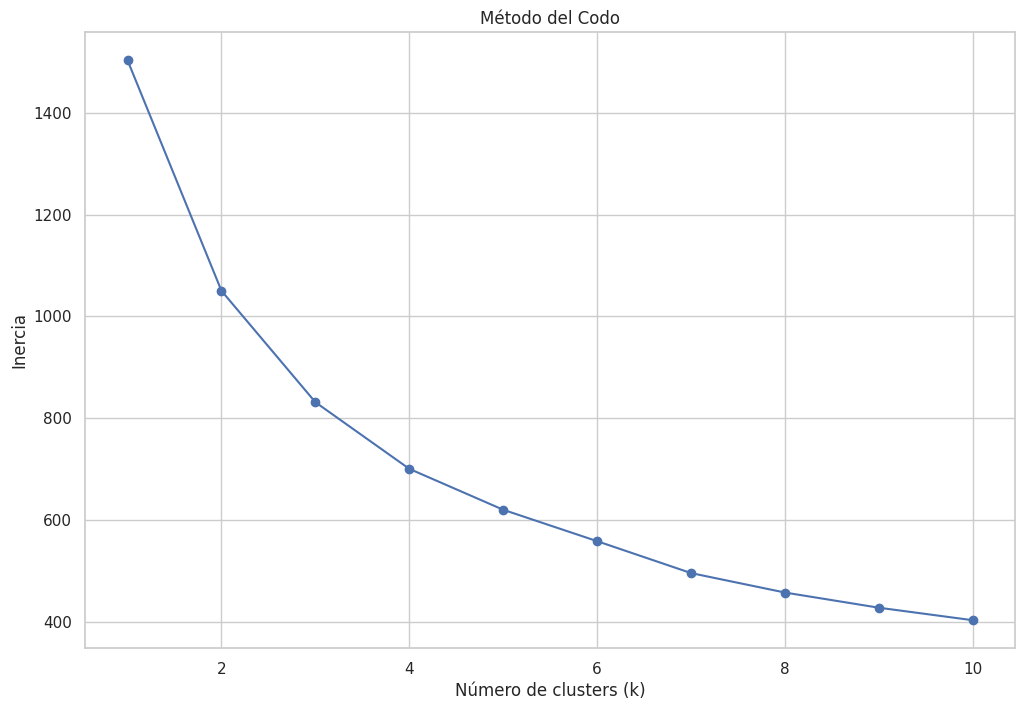

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()


2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

El codo se ubica en k = 3. Hasta este punto la inercia disminuye de forma significativa, pero a partir de ahí la reducción es mucho más gradual.

3. Calcula y grafica el coeficiente de silueta

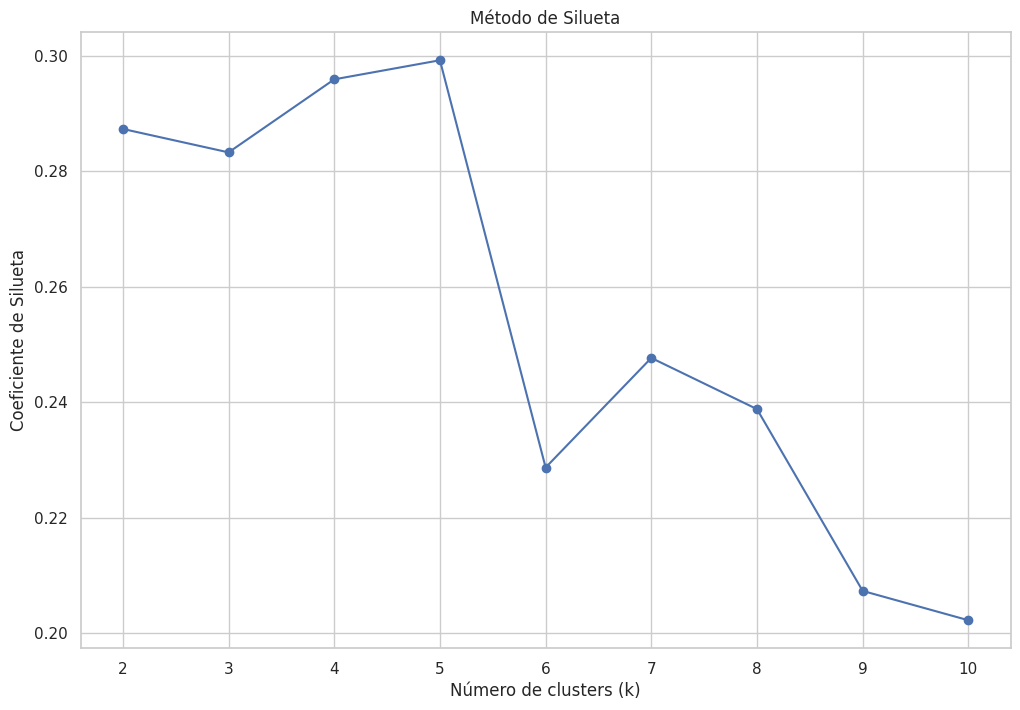

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# Graficar
plt.figure()
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Método de Silueta')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

El número de clusters más adecuado es k = 5, ya que presenta el valor más alto del coeficiente de silueta.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

Se decide utilizar k = 3 clusters.

Aunque el coeficiente de silueta alcanza su valor máximo en k=5, la diferencia frente a k=3 y k=4 no es muy grande. Por otro lado, el método del codo muestra claramente un punto de inflexión en k=3, lo que indica que a partir de ahí las mejoras son marginales.

6. Aplica K-Means con el k que tu grupo eligió.

In [ ]:
from sklearn.cluster import KMeans

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Agregar los clusters al dataset original
df['cluster'] = clusters

df['cluster'].value_counts()


,count
cluster,
2,84
1,47
0,36


7. Añade la asignación de clusters al DataFrame original

In [ ]:
df['cluster'] = clusters


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [ ]:
df.groupby('cluster').mean(numeric_only=True)
df.groupby('cluster').mean(numeric_only=True).round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,"45,672.22",2.67,80.13,1.75,"42,494.44"
1,92.96,29.15,6.39,42.32,"3,942.40",12.02,59.19,5.01,"1,922.38"
2,21.93,40.24,6.20,47.47,"12,305.60",7.60,72.81,2.31,"6,486.45"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

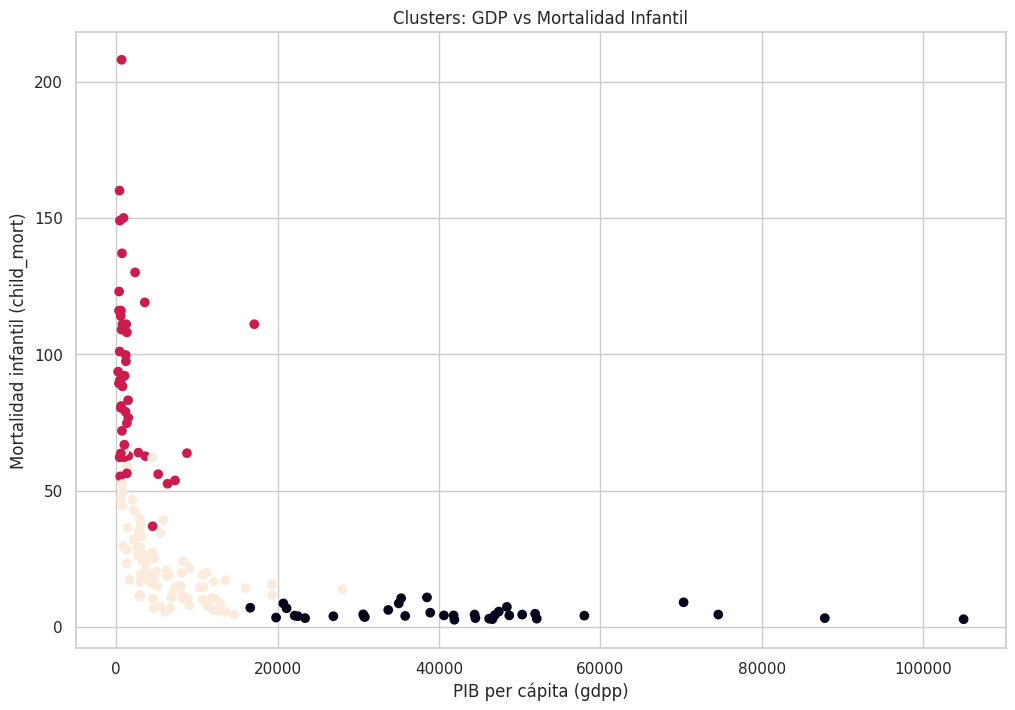

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df['gdpp'], df['child_mort'], c=df['cluster'])

plt.xlabel('PIB per cápita (gdpp)')
plt.ylabel('Mortalidad infantil (child_mort)')
plt.title('Clusters: GDP vs Mortalidad Infantil')

plt.show()

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.

Se pueden identificar tres grupos: países desarrollados, países en desarrollo y países vulnerables.

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.

El cluster de países desarrollados se caracteriza por un alto PIB per cápita y muy baja mortalidad infantil. Estos países tienen mejores condiciones de vida, sistemas de salud sólidos y mayor estabilidad económica.

El cluster de países en desarrollo presenta niveles intermedios tanto en ingreso como en mortalidad infantil. Son economías en crecimiento, con avances en salud y educación, pero que aún enfrentan desafíos estructurales.

El cluster de países vulnerables agrupa países con bajo PIB per cápita y alta mortalidad infantil. Esto refleja limitaciones en acceso a servicios básicos, sistemas de salud débiles y mayores niveles de pobreza.


5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.


Para el cluster de países vulnerables, el PNUD debería implementar programas enfocados en el fortalecimiento del sistema de salud primaria, nutrición infantil y acceso a servicios básicos. Este tipo de intervención puede reducir significativamente la mortalidad infantil y sentar las bases para un desarrollo económico más sostenible.